In [4]:
import numpy as np # generic math functions
from scipy.optimize import OptimizeResult, minimize, curve_fit # optimization functions
import matplotlib.pyplot as plt # plotting library
from typing import Sequence


from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import efficient_su2, StatePreparation, EvolvedOperatorAnsatz, hamiltonian_variational_ansatz
#from qiskit_algorithms import VQE, VQEResult
#from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
#from qiskit_algorithms.optimizers import COBYLA

### Define Constants

In [ ]:
g = 0.5
Ns = np.array([4, 6, 8, 10, 12])
h_bar = 1.0
hs = Ns * h_bar

### Select Backend
Note: code to run on real hardware has depracated.

In [ ]:
# For real hardware:
"""
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2, Estimator
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.least_busy(operational=True, simulator=False)
estimator = Estimator(backend)
sampler = SamplerV2(backend)

"""

# For simulator
from qiskit_aer.primitives import SamplerV2, EstimatorV2
backend = AerSimulator(noise_model=None)
estimator = EstimatorV2()
sampler = SamplerV2()


In [ ]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        g (float): Transverse field strength
    Returns:
        float: Energy estimate
    """
    
    pub = (ansatz, [hamiltonian], params)
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    energy = result.data.evs[0]
    
    
    
    return energy

In [ ]:
def get_vqe_gs(hamiltonian, ansatz, estimator, num_runs=1):
    """Run VQE to find ground state energy and parameters
    Parameters:
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        estimator (EstimatorV2): Estimator primitive instance
        num_runs (int): Number of VQE runs with different initial parameters
    Returns:
        ndarray: Optimal parameters found by VQE
    """


    num_params = ansatz.num_parameters
    
    x0 = 0.01 * np.random.randn(num_params)   # near zero
    estimator.options.default_shots = 5000
    options = {'maxiter': 5000, 'rhobeg': 0.1}
    
    # Run VQE num_runs times with different initial parameters and take the best result
    energy = np.inf
    for seed in range(num_runs):
        x0 = 0.01 * np.random.randn(num_params)   # near zero
        res = minimize(
            cost_func,
            x0,
            args=(ansatz, hamiltonian, estimator),
            method="cobyla",  
            options=options
        )
        if res.fun < energy:
            energy = res.fun
            final_params = res.x

    return final_params


In [ ]:
def get_symm_broken_ansatz(N, num_layers=1):
    """Return a Z_2 symmetry-broken ansatz circuit for the TFIM
    Parameters:
        N (int): Number of qubits
        num_layers (int): Number of layers in the ansatz
    Returns:
        QuantumCircuit: Parameterized ansatz circuit
    """
    

    thetas = ParameterVector('th', 3*num_layers)
    lams = ParameterVector('lam', 3*num_layers)
    phis = ParameterVector('phi', num_layers)
    sigs = ParameterVector('sig', num_layers)
    chis = ParameterVector('chi', num_layers)

    symm_ansatz = QuantumCircuit(N)
    symm_ansatz.x([n for n in range(N//2 -1)])
    symm_ansatz.x([n for n in range(N//2, N-1)])
    symm_ansatz.h([n for n in range(N)])
    for layer in range(num_layers):
        # Apply sigma gates between qubits n and N-2-n
        for n in range(N//2 - 1):
            symm_ansatz.rzz(thetas[0 + 3*layer], n, N-2-n)
            symm_ansatz.ryy(thetas[1 + 3*layer], n, N-2-n)
            symm_ansatz.rxx(thetas[2 + 3*layer], n, N-2-n)
        symm_ansatz.barrier()
        # Apply U gates
        symm_ansatz.u(phis[layer], chis[layer], sigs[layer], [n for n in range(N-1)])
        symm_ansatz.u(lams[3*layer], lams[3*layer+1], lams[3*layer+2], N-1)
    return symm_ansatz


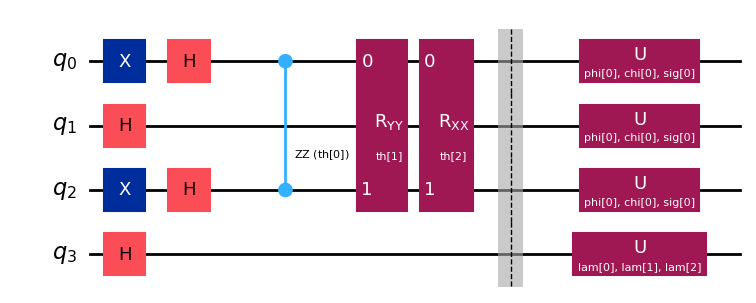

In [7]:
ansatz = get_symm_broken_ansatz(N=4, num_layers=1)
ansatz.draw('mpl')

In [ ]:
def H_tfi(N, g=1.0, J=1.0, h=0, PBC=True):
    """Construct the transverse field Ising model Hamiltonian as a SparsePauliOp
    Parameters:
        N (int): Number of spins
        g (float): Transverse field strength
        J (float): Coupling strength
        h (float): Symmetry-breaking parameter acting on the last spin
        PBC (bool): Whether to use periodic boundary conditions (ZZ between last and first spin)
    Returns:
        SparsePauliOp: Hamiltonian operator
    """

    J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    if PBC:
        J_zz.append(("ZZ", [N-1, 0], -J))
    
    g_field = [("X", [n], -g) for n in range(N)]
    h_field = [("Z", [N-1], -h)]
    
    operator_tuples = [*h_field, *g_field, *J_zz]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

In [9]:
hamiltonians_dict = {}
ansatz_dict = {}

for i, N in enumerate(Ns):
    ansatz_dict[N] = get_symm_broken_ansatz(N, num_layers=N//2)
    hamiltonians_dict[N] = H_tfi(N, g=g, J=1.0, h=hs[i], PBC=True)


In [ ]:
magnetization_qiskit = np.zeros(len(Ns))
magnetization_err = np.zeros(len(Ns))

for i, N in enumerate(Ns):
    hamiltonian = hamiltonians_dict[N]
    ansatz = ansatz_dict[N]
    final_params = get_vqe_gs(hamiltonian, ansatz, estimator, num_runs=3)
    print(f'Computed ground state for N={N}')

    M_op_list = [("Z", [n], 0.5) for n in range(N)]
    M_op = SparsePauliOp.from_sparse_list(M_op_list, num_qubits=N)
    pub = (ansatz, [M_op], final_params)
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    mz_exp = result.data.evs[0]
    magnetization_qiskit[i] = mz_exp / N
    magnetization_err[i] = result.data.stds

In [ ]:
#write data to file
"""
with open('Ising_sb_VQE_g={}_data.txt'.format(g), 'w') as f:
    f.write('# N  Magnetization_per_site\n')
    for i, N in enumerate(Ns):
        f.write(f'{N}  {magnitization_arr[i]}\n')
"""

## Compare with exact quspin result

In [ ]:
import numpy as np # generic math functions
#from scipy.optimize import curve_fit
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases
from quspin.tools.measurements import ED_state_vs_time, obs_vs_time
from quspin.tools.evolution import evolve

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection


In [ ]:
##### define model parameters #####

def H_tfi_quspin(N, J=1.0, g=1.0, h=0.0, PBC=True):
    """Construct the transverse field Ising model Hamiltonian as a quspin hamiltonian
    Parameters:
        N (int): Number of spins
        J (float): Coupling strength
        g (float): Transverse field strength
        h (float): Symmetry-breaking parameter acting on the last spin
        PBC (bool): Whether to use periodic boundary conditions (ZZ between last and first spin)
    Returns:
        H_spin (hamiltonian): QuSpin Hamiltonian object
    """ 

    g_field=[[-g,i] for i in range(N)]
    J_zz=[[-J, i, i+1] for i in range(N-1)]
    if PBC:
        J_zz.append([-J, N-1, 0])
    
    h_field = [[-h, N-1]]
         
    static_spin = [["zz", J_zz], ["x", g_field], ["z" ,h_field]]
    dynamic_spin = []
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [ ]:
magnetization_quspin = np.zeros(len(Ns))
dense = True

for i, N in enumerate(Ns):
    H = hamiltonians_dict[N].to_matrix(sparse=False)
    if dense:
        E, V = np.linalg.eigh(H)
        V = V[:, 0]
    else:
        E, V = H.eigsh(k=1, which='SA')
        V = V[:, 0]

    magnetization_list = [[0.5, n] for n in range(N)]
    magnetization_operator_list = [["z", [[0.5, n] for n in range(N)]]]
    magnetization_operator_dict = dict(Z=magnetization_operator_list)
    mz_op = quantum_operator(magnetization_operator_dict, basis=spin_basis_1d(L=int(N)), dtype=np.complex64, check_herm=False, check_symm=False)
    mz_exp = mz_op.expt_value(V)
    magnetization_quspin[i] = mz_exp / N 


## Both data sets in the same plot

In [21]:
def linear_func(x, a, b):
    return a * x + b

x_fit = np.linspace(0, np.max(1/Ns), 100)


popt_qiskit, pcov_qiskit = curve_fit(linear_func, 1/Ns, magnetization_qiskit, sigma=magnetization_err)

qiskit_y_pred = linear_func(x_fit, *popt_qiskit)
dy_qiskit = np.sqrt(pcov_qiskit[0, 0] * x_fit**2 + pcov_qiskit[1, 1] + 2 * pcov_qiskit[0, 1] * x_fit)
upper_band_qiskit = qiskit_y_pred + 2*dy_qiskit
lower_band_qiskit = qiskit_y_pred - 2*dy_qiskit

popt_quspin, pcov_quspin = curve_fit(linear_func, 1/Ns, magnetization_quspin)

quspin_y_pred = linear_func(x_fit, *popt_quspin)
dy_quspin = np.sqrt(pcov_quspin[0, 0] * x_fit**2 + pcov_quspin[1, 1] + 2 * pcov_quspin[0, 1] * x_fit)
upper_band_quspin = quspin_y_pred + 2*dy_quspin
lower_band_quspin = quspin_y_pred - 2*dy_quspin

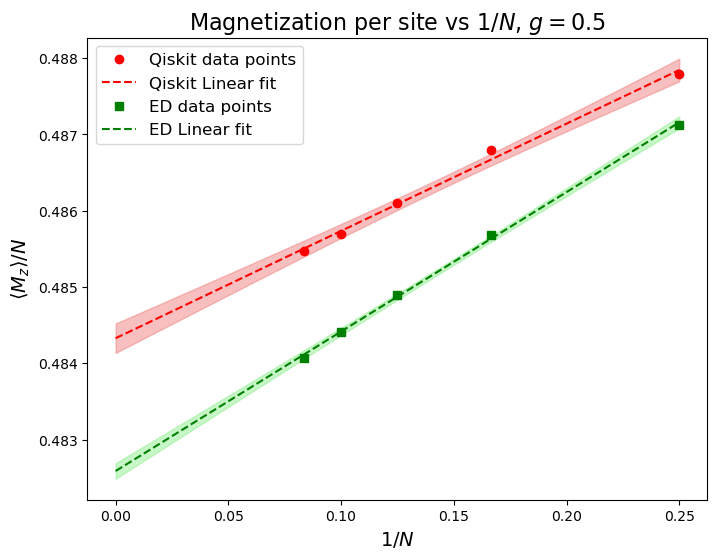

In [25]:

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(1/Ns, magnetization_qiskit, 'ro', label='Qiskit data points')
#ax.errorbar(1/Ns, magnetization_qiskit, yerr=magnetization_err, fmt='.', label='Qiskit data points', capsize=5)
ax.plot(x_fit, popt_qiskit[0]*x_fit + popt_qiskit[1], 'r--', label='Qiskit Linear fit')
ax.fill_between(x_fit, upper_band_qiskit, lower_band_qiskit, color='lightcoral', alpha=0.5)

ax.plot(1/Ns, magnetization_quspin, 'gs', label='ED data points')
ax.plot(x_fit, popt_quspin[0]*x_fit + popt_quspin[1], 'g--', label='ED Linear fit')
ax.fill_between(x_fit, upper_band_quspin, lower_band_quspin, color='lightgreen', alpha=0.5)
#ax.plot(0, popt_qiskit[1], 'x', color='black', label='Qiskit Extrapolated value at $N \\to \\infty$')
#ax.plot(0, popt_quspin[1], '^', color='blue', label='QuSpin Extrapolated value at $N \\to \\infty$')
ax.legend(fontsize=12)
ax.set_xlabel('1/$N$', fontsize=14)
ax.set_ylabel(r'$\langle M_z \rangle / N$', fontsize=14)
ax.set_title('Magnetization per site vs 1/$N$, $g=${}'.format(g), fontsize=16)
plt.show()

## Extrapolated values at $N\to \infty$

In [23]:
## Extrapolated values at N -> infinity
print('Qiskit extrapolated magnetization per site at N->infinity: {:.4f} +/- {:.4f}'.format(popt_qiskit[1], 2*np.sqrt(pcov_qiskit[1, 1])))
print('QuSpin extrapolated magnetization per site at N->infinity: {:.4f} +/- {:.4f}'.format(popt_quspin[1], 2*np.sqrt(pcov_quspin[1, 1])))

Qiskit extrapolated magnetization per site at N->infinity: 0.4843 +/- 0.0002
QuSpin extrapolated magnetization per site at N->infinity: 0.4826 +/- 0.0001


In [24]:
relative_error = np.abs(popt_qiskit[1] - popt_quspin[1]) / np.abs(popt_quspin[1])
print('Relative error between Qiskit and QuSpin extrapolated values: {:.4f}'.format(relative_error))

Relative error between Qiskit and QuSpin extrapolated values: 0.0036
